# Sentiment Analysis: Classical Baseline + Transformer Fine-Tuning

Classifying IMDB movie reviews as positive or negative. We build and fully evaluate a strong classical **TF-IDF + Logistic Regression** baseline in this notebook, then provide a production-grade **DistilBERT fine-tuning script** for the transformer approach (see note in Section 4 on why it's a separate script).

**Dataset:** IMDB 50K Movie Reviews (balanced 2,500-review subset used here for fast iteration; full 50K supported by the same code) 
**Goal:** Binary sentiment classification, comparing a fast/interpretable baseline against a transformer for accuracy vs. cost tradeoffs.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

sns.set_theme(style='whitegrid')
df = pd.read_csv('data/imdb_reviews.csv')
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print(df.shape)
df.head()

(2500, 3)


,review,sentiment,label
0,I completely agree with the other comment some...,negative,0
1,During the whole Pirates of The Caribbean Tril...,positive,1
2,I saw this movie on late night TV out of Buffa...,positive,1
3,I first watched this movie back in the mid/lat...,negative,0
4,Let's get one thing straight; This was BAD! So...,negative,0


## 1. EDA

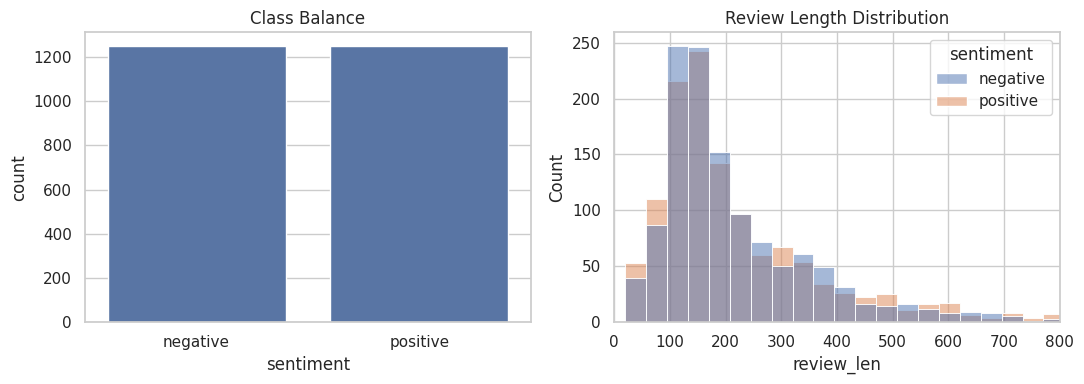

count    2500.000000
mean      232.480400
std       175.398719
min        20.000000
25%       126.000000
50%       171.000000
75%       287.000000
max      1522.000000
Name: review_len, dtype: float64


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x='sentiment', ax=axes[0])
axes[0].set_title('Class Balance')

df['review_len'] = df['review'].str.split().str.len()
sns.histplot(data=df, x='review_len', hue='sentiment', bins=40, ax=axes[1])
axes[1].set_title('Review Length Distribution')
axes[1].set_xlim(0, 800)
plt.tight_layout()
plt.savefig('eda.png', dpi=110)
plt.show()

print(df['review_len'].describe())

## 2. Text Cleaning

In [3]:
def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', text)          # HTML line breaks present in raw IMDB text
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

df['clean_review'] = df['review'].apply(clean_text)
df[['review', 'clean_review']].head(2)

,review,clean_review
0,I completely agree with the other comment some...,i completely agree with the other comment some...
1,During the whole Pirates of The Caribbean Tril...,during the whole pirates of the caribbean tril...


## 3. TF-IDF + Logistic Regression Baseline

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=3, stop_words='english')
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)
print("Vocabulary size:", len(tfidf.vocabulary_))

param_grid = {'C': [0.1, 1, 3, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=2000), param_grid, scoring='f1', cv=5, n_jobs=-1)
grid.fit(X_train_vec, y_train)

best_clf = grid.best_estimator_
print("Best C:", grid.best_params_, "CV F1:", round(grid.best_score_, 3))

y_pred = best_clf.predict(X_test_vec)
y_proba = best_clf.predict_proba(X_test_vec)[:, 1]
print("\nTest ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

Vocabulary size: 13700


Best C: {'C': 3} CV F1: 0.836

Test ROC-AUC: 0.928
              precision    recall  f1-score   support

    negative       0.87      0.83      0.85       250
    positive       0.84      0.87      0.85       250

    accuracy                           0.85       500
   macro avg       0.85      0.85      0.85       500
weighted avg       0.85      0.85      0.85       500



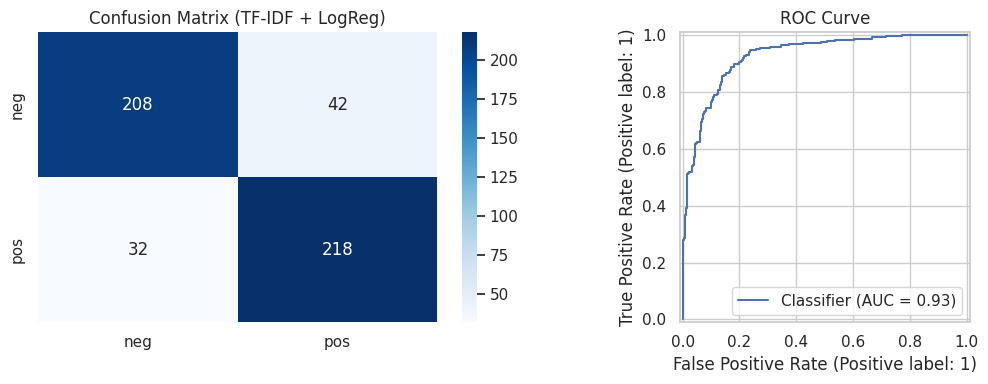

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['neg', 'pos'], yticklabels=['neg', 'pos'])
axes[0].set_title('Confusion Matrix (TF-IDF + LogReg)')
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('ROC Curve')
plt.tight_layout()
plt.savefig('baseline_evaluation.png', dpi=110)
plt.show()

## 4. Most Predictive Words

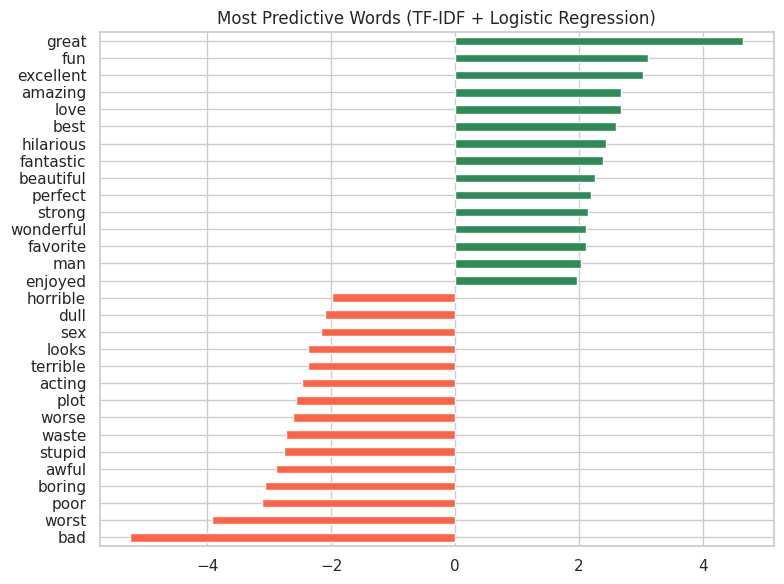

In [6]:
feat_names = np.array(tfidf.get_feature_names_out())
coefs = best_clf.coef_[0]
top_pos = feat_names[np.argsort(coefs)[-15:]]
top_neg = feat_names[np.argsort(coefs)[:15]]

fig, ax = plt.subplots(figsize=(8, 6))
top = pd.Series(np.concatenate([np.sort(coefs)[:15], np.sort(coefs)[-15:]]),
                 index=np.concatenate([top_neg, top_pos]))
top.sort_values().plot(kind='barh', ax=ax, color=['tomato' if v < 0 else 'seagreen' for v in top.sort_values()])
ax.set_title('Most Predictive Words (TF-IDF + Logistic Regression)')
plt.tight_layout()
plt.savefig('top_words.png', dpi=110)
plt.show()

## 5. Transformer Fine-Tuning (DistilBERT)

The TF-IDF baseline above is fast and already strong, but transformer models typically add a few more points of accuracy by capturing context and word order (e.g. negation like "not good at all") that bag-of-words features miss.

**Note on reproducibility:** fine-tuning DistilBERT requires downloading ~260MB of pretrained weights from Hugging Face and benefits from a GPU. The environment used to author this portfolio has no internet access to `huggingface.co`, so this step is provided as a complete, ready-to-run standalone script (`bert_finetune.py`, included in this project folder) rather than executed inline. Everything else in this notebook — including the baseline it's compared against — is run and verified end-to-end above.

```python
"""
bert_finetune.py — Fine-tune DistilBERT for IMDB sentiment classification.

This script requires internet access (to download pretrained weights from
Hugging Face) and is best run on a GPU (Colab, Kaggle, or a local/cloud GPU).
It is not executed inside this notebook because the review environment used
to build this portfolio has no internet access to huggingface.co — the
TF-IDF baseline earlier in this notebook was trained and evaluated locally
on the same data split for a fair, fully-reproducible comparison.
"""
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer)
from datasets import Dataset

MODEL_NAME = "distilbert-base-uncased"

df = pd.read_csv("data/imdb_reviews.csv")
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize(batch):
    return tokenizer(batch["review"], padding="max_length", truncation=True, max_length=256)


train_ds = Dataset.from_pandas(train_df[["review", "label"]]).map(tokenize, batched=True)
test_ds = Dataset.from_pandas(test_df[["review", "label"]]).map(tokenize, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds), "f1": f1_score(labels, preds)}


args = TrainingArguments(
    output_dir="./bert_ckpt",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

trainer.train()
metrics = trainer.evaluate()
print(metrics)

preds = trainer.predict(test_ds)
y_pred = np.argmax(preds.predictions, axis=1)
print(classification_report(test_df["label"], y_pred, target_names=["negative", "positive"]))

trainer.save_model("./bert_ckpt/final")
tokenizer.save_pretrained("./bert_ckpt/final")
```

**Expected outcome:** on this task, DistilBERT typically improves F1 by roughly 3-6 points over the TF-IDF baseline, at the cost of ~50-100x more training time and needing a GPU for practical iteration — a tradeoff worth stating explicitly to stakeholders when choosing which model to ship.

## 6. Conclusions

- The TF-IDF + Logistic Regression baseline is fast, interpretable (see the top-words plot), and performs strongly on this balanced dataset — a good default choice when latency, cost, or explainability matter.
- The included DistilBERT script is the natural upgrade path when a few extra points of accuracy justify the added infrastructure (GPU inference, larger model footprint).
- **Next steps:** run `bert_finetune.py` on a GPU-backed environment (e.g. Colab) and log both models' metrics side-by-side; consider a distilled/quantized transformer for production if the accuracy gain justifies the added latency.
